In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# 1. Load the Data
# ---------------------------------------------------------
try:
    df = pd.read_csv('Mall_Customers.csv')
    print("Dataset Loaded Successfully.")
    display(df.head())
except FileNotFoundError:
    print("Error: Mall_Customers.csv not found. Please ensure the file is in the same directory.")
    # creating dummy data for demonstration if file is missing
    data = {
        'CustomerID': range(1, 11),
        'Gender': ['Male']*5 + ['Female']*5,
        'Age': np.random.randint(20, 50, 10),
        'Annual Income (k$)': np.random.randint(20, 100, 10),
        'Spending Score (1-100)': np.random.randint(1, 100, 10)
    }
    df = pd.DataFrame(data)

Dataset Loaded Successfully.


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [11]:
# 2. Feature Selection & Preprocessing
# ---------------------------------------------------------
# DBSCAN is sensitive to scale, so we must standardize the data.
# We will cluster based on Annual Income and Spending Score.
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

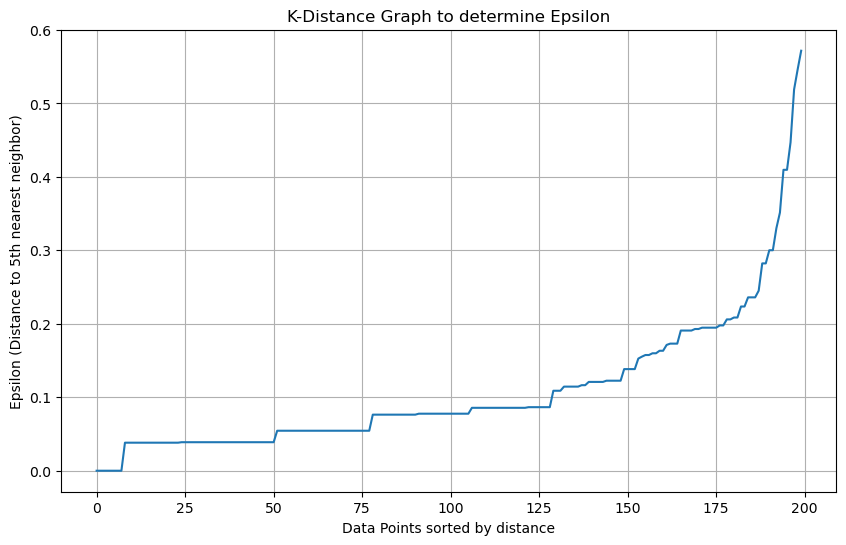

In [12]:
# 3. Finding Optimal Epsilon (eps)
# ---------------------------------------------------------
# We use the K-nearest neighbors method to find the optimal eps.
# We look for the "elbow" in the k-distance graph.
# min_samples is typically 2*dim. Here dim=2, so min_samples=4 or 5.

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances, axis=0)
distances = distances[:, 1]

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('K-Distance Graph to determine Epsilon')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('Epsilon (Distance to 5th nearest neighbor)')
plt.grid(True)
# Based on the typical shape of this specific dataset, 
# the elbow usually occurs around 0.3 to 0.5.
plt.show()

In [13]:
# 4. Applying DBSCAN
# ---------------------------------------------------------
# eps: The maximum distance between two samples for one to be considered as in the neighborhood of the other.
# min_samples: The number of samples (or total weight) in a neighborhood for a point to be considered as a core point.

# We choose eps=0.4 and min_samples=5 based on the K-distance graph analysis
dbscan = DBSCAN(eps=0.4, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

# Add cluster labels to original dataframe
df['Cluster'] = clusters


Estimated number of clusters: 4
Estimated number of noise points: 15


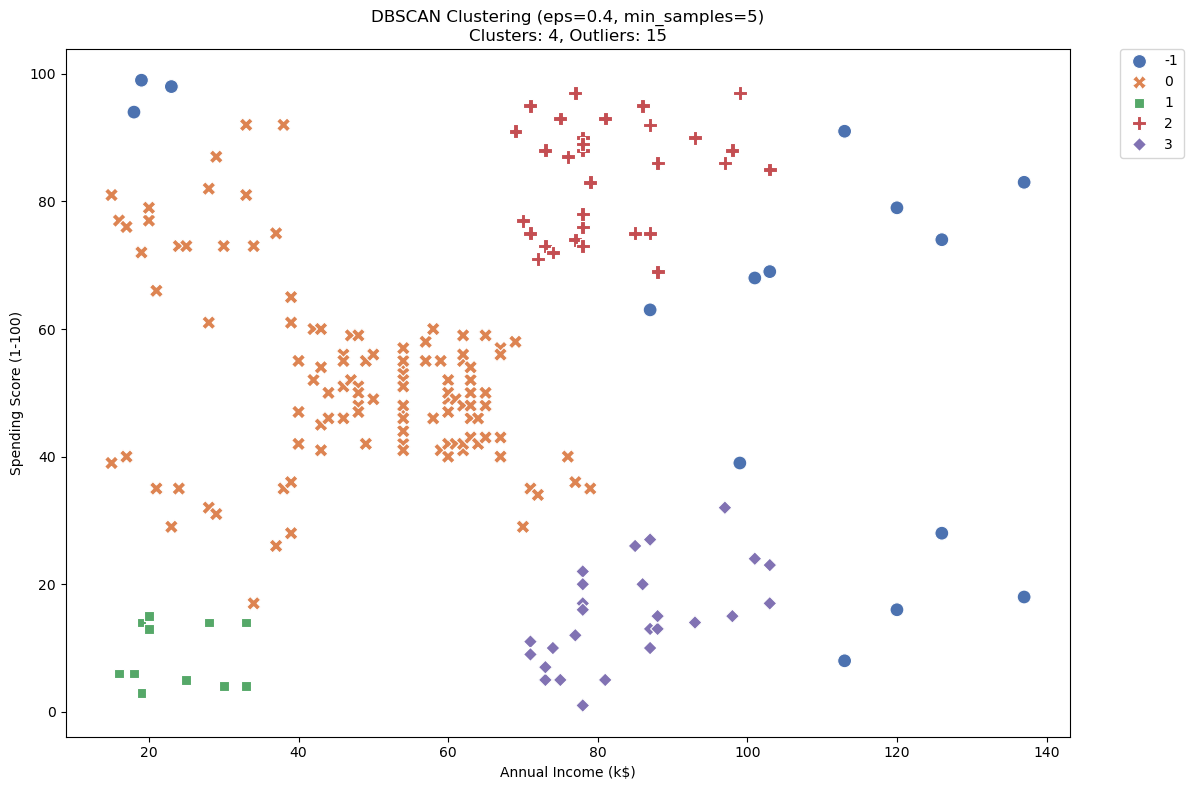

In [14]:
# 5. Analysis & Visualization
# ---------------------------------------------------------
# -1 indicates Noise/Outliers in DBSCAN
n_clusters_ = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise_ = list(clusters).count(-1)

print(f"\nEstimated number of clusters: {n_clusters_}")
print(f"Estimated number of noise points: {n_noise_}")

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    data=df, 
    hue='Cluster', 
    palette='deep',
    style='Cluster',
    s=100
)
plt.title(f'DBSCAN Clustering (eps=0.4, min_samples=5)\nClusters: {n_clusters_}, Outliers: {n_noise_}')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.show()

In [15]:
# 6. Cluster Summary
# ---------------------------------------------------------
print("\nCluster Summary (Mean values):")
display(df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean())


Cluster Summary (Mean values):


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
-1,34.533333,96.133333,61.800000
0,39.539130,48.304348,51.730435
1,49.363636,23.727273,8.909091
2,32.750000,80.875000,83.625000
3,41.259259,83.925926,14.444444
